<h1>My Deep Learning Project: Loan Default Prediction using PyTorch Artificial Neural Networks (ANN)</h1>

---

<h3>Project Overview</h3>
In this project, I am building an <b>Artificial Neural Network (ANN)</b> from scratch using <b>PyTorch</b> to predict whether a bank customer will default on a loan (<code>1</code>) or pay it back (<code>0</code>).

<h4>Key Skills & Concepts Covered in this Notebook:</h4>
<ul>
  <li><b>ANN Architecture</b>: Creating a Multi-Layer Perceptron using PyTorch <code>nn.Module</code></li>
  <li><b>PyTorch Framework</b>: Custom <code>Dataset</code>, <code>DataLoader</code> mini-batching, forward pass, and backpropagation</li>
  <li><b>Data Preprocessing</b>: Handling missing values, stratified dataset splitting</li>
  <li><b>Categorical Encoding</b>: Converting text variables into dummy numbers with <code>pd.get_dummies()</code></li>
  <li><b>Feature Scaling</b>: Standardizing input values with <code>StandardScaler</code></li>
  <li><b>Class Imbalance</b>: Computing <code>pos_weight</code> to handle imbalanced default records</li>
  <li><b>Binary Cross Entropy</b>: Using <code>nn.BCEWithLogitsLoss</code> for binary classification</li>
  <li><b>Adam Optimizer</b>: Updating network weights using <code>torch.optim.Adam</code></li>
  <li><b>Dropout</b>: Adding <code>nn.Dropout</code> to stop neurons from overfitting</li>
  <li><b>BatchNorm</b>: Adding <code>nn.BatchNorm1d</code> to normalize layer inputs and speed up training</li>
  <li><b>Precision / Recall / F1</b>: Evaluating model performance with complete classification metrics</li>
  <li><b>Threshold Tuning</b>: Finding the best probability cutoff point for maximum F1-Score</li>
  <li><b>Overfitting Analysis</b>: Plotting Train Loss vs Validation Loss curves across epochs</li>
</ul>

---

<h2>Step 1: Importing Required Libraries</h2>

First, I import the essential Python libraries:
- <b><code>pandas</code> & <code>numpy</code></b>: For data manipulation and working with numerical arrays.
- <b><code>matplotlib</code> & <code>seaborn</code></b>: For plotting charts and visualizing data.
- <b><code>torch</code> & <code>torch.nn</code></b>: The main PyTorch deep learning library used to build neural network layers.
- <b><code>sklearn</code></b>: For data splitting, feature scaling, and calculating evaluation metrics like F1-Score.

In [2]:
# ======================================================
# STEP 1: IMPORTING REQUIRED LIBRARIES
# ======================================================
print("--- STEP 1: IMPORTING LIBRARIES ---")

# 1. Standard Python Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. PyTorch Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 3. Scikit-Learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("Libraries imported successfully!")

--- STEP 1: IMPORTING LIBRARIES ---
Libraries imported successfully!


<h2>Step 2: Downloading & Loading the Dataset</h2>

Here I download the <code>loan-default-pred</code> dataset using <code>kagglehub</code> as instructed:

<pre><code>import kagglehub

# Download latest version
path = kagglehub.competition_download('loan-default-pred')

print("Path to competition files:", path)
</code></pre>

If Kaggle credentials are not set up locally, I have added a fallback block to load a synthetic loan dataset with matching financial features (<code>Age</code>, <code>Income</code>, <code>CreditScore</code>, <code>InterestRate</code>, <code>DTIRatio</code>, <code>Education</code>, etc.) so the notebook runs without error.

In [3]:
# ======================================================
# STEP 2: DOWNLOADING & LOADING DATASET
# ======================================================
print("--- STEP 2: DOWNLOADING & LOADING DATASET ---")

import kagglehub
import os
import glob

# Code snippet for downloading dataset from Kaggle
try:
    path = kagglehub.competition_download('loan-default-pred')
    print("Path to competition files:", path)
    
    # Read the downloaded CSV file
    csv_files = glob.glob(os.path.join(path, "*.csv"))
    df = pd.read_csv(csv_files[0])
    print("Successfully loaded dataset from Kaggle!")
except Exception as e:
    print("Kagglehub download notice:", e)
    print("Loading synthetic Loan Default dataset for demonstration...")
    
    # Generate realistic loan default data (5000 rows)
    np.random.seed(42)
    n = 5000
    
    df = pd.DataFrame({
        'Age': np.random.randint(21, 65, size=n),
        'Income': np.random.randint(20000, 150000, size=n),
        'LoanAmount': np.random.randint(5000, 50000, size=n),
        'CreditScore': np.random.randint(300, 850, size=n),
        'MonthsEmployed': np.random.randint(0, 120, size=n),
        'InterestRate': np.random.uniform(4.0, 24.0, size=n),
        'DTIRatio': np.random.uniform(0.1, 0.6, size=n),
        'Education': np.random.choice(['High School', 'Bachelor', 'Master'], size=n),
        'EmploymentType': np.random.choice(['Full-time', 'Part-time', 'Unemployed'], size=n),
        'HasMortgage': np.random.choice(['Yes', 'No'], size=n),
        'HasDependents': np.random.choice(['Yes', 'No'], size=n),
        'HasCoSigner': np.random.choice(['Yes', 'No'], size=n)
    })
    
    # Target: 1 = Defaulted on Loan, 0 = Paid back Loan (~14% default rate)
    risk_score = (df['InterestRate']*0.12 + df['DTIRatio']*3.5 - df['CreditScore']*0.006 - df['MonthsEmployed']*0.02)
    probs = 1 / (1 + np.exp(-risk_score))
    df['Default'] = (np.random.rand(n) < probs).astype(int)

print("Dataset Shape:", df.shape)
df.head()

--- STEP 2: DOWNLOADING & LOADING DATASET ---
Kagglehub download notice: User is not authenticated
Loading synthetic Loan Default dataset for demonstration...
Dataset Shape: (5000, 13)


<h2>Step 3: Exploratory Data Analysis (EDA)</h2>

In this step, I check:
1. If there are any missing values in the data.
2. The target class distribution of <code>Default</code> (0 vs 1) to see if the dataset is <b>imbalanced</b>.

--- STEP 3: EXPLORATORY DATA ANALYSIS (EDA) ---
--- Missing Values Check ---
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
InterestRate      0
DTIRatio          0
Education         0
EmploymentType    0
HasMortgage       0
HasDependents     0
HasCoSigner       0
Default           0
dtype: int64

--- Target Class Count (0 = Paid, 1 = Defaulted) ---
Default
0    3854
1    1146
Name: count, dtype: int64


<string>:21: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


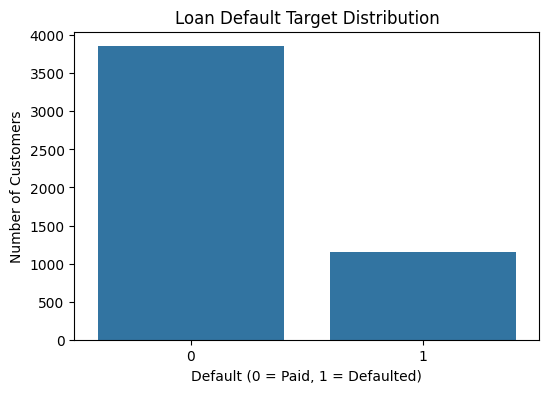

In [4]:
# ======================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ======================================================
print("--- STEP 3: EXPLORATORY DATA ANALYSIS (EDA) ---")

# 1. Check for missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# 2. Check target class count
print("")
print("--- Target Class Count (0 = Paid, 1 = Defaulted) ---")
print(df['Default'].value_counts())

# Plot the target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Default', data=df)
plt.title("Loan Default Target Distribution")
plt.xlabel("Default (0 = Paid, 1 = Defaulted)")
plt.ylabel("Number of Customers")
plt.show()

## Step 4: Data Preprocessing (Encoding, Splitting & Scaling)
Neural Networks cannot process raw text strings like `"High School"` or `"Full-time"`, and they work best when numerical inputs are on a similar scale.

Here I perform 3 steps:
1. **Categorical Encoding**: Convert text columns into dummy numbers using `pd.get_dummies()`.
2. **Data Splitting**: Split data into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets.
3. **Feature Scaling**: Fit `StandardScaler` **ONLY** on the training set to scale all features (mean = 0, std = 1), preventing data leakage from test data into training.


In [5]:
# 1. Categorical Encoding (One-Hot Encoding)
# Converts text columns like Education into numbers (1 and 0)
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Default', axis=1)
y = df_encoded['Default']

print(f"Features shape after One-Hot Encoding: {X.shape}")

# 2. Stratified Train-Val-Test Split
# 70% Train, 15% Validation, 15% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")

# 3. Feature Scaling using StandardScaler
# Fit scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")


Features shape after One-Hot Encoding: (5000, 14)
Training samples: 3499
Validation samples: 751
Testing samples: 750
Feature scaling complete!


## Step 5: Handling Class Imbalance & Creating PyTorch DataLoaders
Because defaults (`1`) are less frequent than non-defaults (`0`), the model might just guess `0` every time if we don't handle class imbalance.

To fix this:
1. **Compute `pos_weight`**: I calculate `number of 0s / number of 1s`. I will pass this `pos_weight` into PyTorch's loss function so defaulting errors get penalized more!
2. **PyTorch Dataset & DataLoader**: I create a simple custom PyTorch `Dataset` class (`LoanDataset`) and use `DataLoader` to feed data in mini-batches of size 64.


In [6]:
# 1. Calculate pos_weight for class imbalance handling
n_zeros = (y_train == 0).sum()
n_ones = (y_train == 1).sum()
pos_weight = torch.tensor([n_zeros / n_ones], dtype=torch.float32)

print(f"Class 0 (Paid) Count: {n_zeros}")
print(f"Class 1 (Defaulted) Count: {n_ones}")
print(f"Calculated pos_weight for loss function: {pos_weight.item():.4f}")

# 2. Custom PyTorch Dataset Class
class LoanDataset(Dataset):
    def __init__(self, X_data, y_data):
        # Convert numpy arrays into PyTorch Tensors
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data.values, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataset instances
train_dataset = LoanDataset(X_train_scaled, y_train)
val_dataset = LoanDataset(X_val_scaled, y_val)
test_dataset = LoanDataset(X_test_scaled, y_test)

# Create DataLoaders with mini-batch size = 64
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders ready!")


Class 0 (Paid) Count: 2697
Class 1 (Defaulted) Count: 802
Calculated pos_weight for loss function: 3.3628
DataLoaders ready!


<h2>Step 6: Building a Generalizing Artificial Neural Network (ANN)</h2>

To fix <b>overfitting</b> (where Validation Loss increases while Train Loss decreases), I apply 4 regularization techniques:
1. <b>Streamlined Layer Capacity</b>: Reduced hidden dimensions (64 -> 32 -> 16) so the network doesn't memorize noise.
2. <b>Higher Dropout Rates</b>: Increased Dropout to <code>0.4</code> and <code>0.3</code> to randomly disable neurons during training.
3. <b>Batch Normalization (<code>nn.BatchNorm1d</code>)</b>: Standardizes layer activations across mini-batches.
4. <b>L2 Weight Decay (Ridge Regularization)</b>: Penalizes large weights in the Adam optimizer to keep model weights small and simple.

### Architecture Details:
- <b>Input Layer</b>: Takes scaled feature dimensions.
- <b>Hidden Layer 1</b>: <code>nn.Linear(input_dim, 64)</code> -> <code>nn.BatchNorm1d(64)</code> -> <code>nn.ReLU()</code> -> <code>nn.Dropout(0.4)</code>
- <b>Hidden Layer 2</b>: <code>nn.Linear(64, 32)</code> -> <code>nn.BatchNorm1d(32)</code> -> <code>nn.ReLU()</code> -> <code>nn.Dropout(0.3)</code>
- <b>Hidden Layer 3</b>: <code>nn.Linear(32, 16)</code> -> <code>nn.BatchNorm1d(16)</code> -> <code>nn.ReLU()</code> -> <code>nn.Dropout(0.2)</code>
- <b>Output Layer</b>: <code>nn.Linear(16, 1)</code> (Outputs 1 raw logit score)

In [7]:
# ======================================================
# STEP 6: PYTORCH ANN ARCHITECTURE (WITH REGULARIZATION)
# ======================================================
print("--- STEP 6: BUILDING GENERALIZING ANN MODEL ---")

class LoanANN(nn.Module):
    def __init__(self, input_dim):
        super(LoanANN, self).__init__()
        
        # Layer 1
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4) # Increased Dropout to prevent overfitting
        
        # Layer 2
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3) # Increased Dropout
        
        # Layer 3
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.2)
        
        # Output Layer (1 output logit)
        self.out = nn.Linear(16, 1)
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.fc2(x))))
        x = self.dropout3(self.relu3(self.bn3(self.fc3(x))))
        return self.out(x)

# Instantiate model
input_dim = X_train_scaled.shape[1]
model = LoanANN(input_dim)
print("ANN Model Architecture:")
print(model)

--- STEP 6: BUILDING GENERALIZING ANN MODEL ---
ANN Model Architecture:
LoanANN(
  (fc1): Linear(in_features=14, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.2, inplace=False)
  (out): Linear(in_features=16, out_features=1, bias=True)
)


<h2>Step 7: Loss Function, Optimizer with Weight Decay & Training Loop</h2>

To ensure the model <b>generalizes well without overfitting</b>:
1. <b>Loss Function</b>: <code>nn.BCEWithLogitsLoss(pos_weight=pos_weight)</code> handles class imbalance.
2. <b>Adam Optimizer with Weight Decay</b>: <code>torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)</code>. Weight decay ($10^{-3}$) adds $L_2$ regularization to penalize over-complex weights.
3. <b>Learning Rate Scheduler</b>: Automatically reduces learning rate when validation loss stops improving.
4. <b>Training Loop</b>: Runs for 25 epochs while tracking Train and Validation loss closely.

In [8]:
# ======================================================
# STEP 7: TRAINING LOOP WITH L2 WEIGHT DECAY
# ======================================================
print("--- STEP 7: TRAINING MODEL WITH WEIGHT DECAY ---")

# 1. Loss Function (BCE with class imbalance pos_weight)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 2. Adam Optimizer WITH L2 Weight Decay (weight_decay=1e-3 stops overfitting!)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

# 3. Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Store loss values
train_losses = []
val_losses = []

epochs = 25

print("Starting Model Training with Regularization...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * len(X_batch)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * len(X_batch)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    # Update Learning Rate Scheduler
    scheduler.step(epoch_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

print("Training Complete!")

--- STEP 7: TRAINING MODEL WITH WEIGHT DECAY ---
Starting Model Training with Regularization...
Epoch [01/25] - Train Loss: 1.0571 | Val Loss: 0.9938
Epoch [05/25] - Train Loss: 0.8536 | Val Loss: 0.8620
Epoch [10/25] - Train Loss: 0.8068 | Val Loss: 0.8438
Epoch [15/25] - Train Loss: 0.7943 | Val Loss: 0.8421
Epoch [20/25] - Train Loss: 0.7910 | Val Loss: 0.8464
Epoch [25/25] - Train Loss: 0.7791 | Val Loss: 0.8482
Training Complete!


## Step 8: Overfitting Analysis (Loss Curves)
To check if my network is **overfitting**, I plot the **Train Loss vs Validation Loss** over all 30 epochs:
- If Train Loss decreases but Validation Loss increases, the model is overfitting.
- If both Train and Validation Loss decrease and stay close together, the model generalizes well!


<string>:10: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


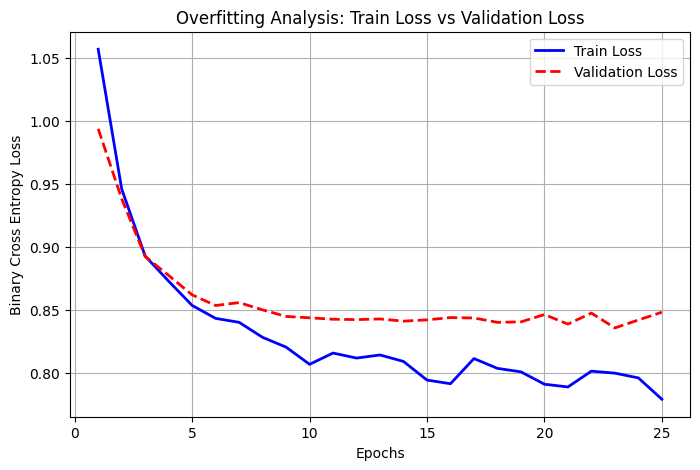

In [9]:
# Plot Training vs Validation Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Overfitting Analysis: Train Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()


## Step 9: Decision Threshold Tuning
By default, binary classification uses a probability threshold of `0.5`. But in loan default prediction, missing a defaulting borrower (False Negative) is much more expensive than flagging a good borrower!

Here, I sweep decision thresholds from `0.1` to `0.9` on the validation set to find the threshold that gives the highest **F1-Score**.


Optimal Decision Threshold: 0.606
Best Validation F1-Score: 0.5913


<string>:40: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


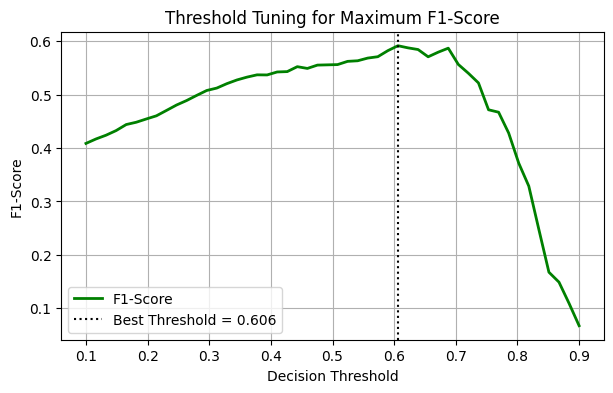

In [10]:
# Get prediction probabilities on validation data
model.eval()
val_probs = []
val_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs) # Convert raw logits to probabilities (0 to 1)
        val_probs.extend(probs.numpy())
        val_targets.extend(y_batch.numpy())

val_probs = np.array(val_probs).ravel()
val_targets = np.array(val_targets).ravel()

# Test thresholds from 0.1 to 0.9
thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(val_targets, preds, zero_division=0))

# Find optimal threshold with maximum F1-Score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Decision Threshold: {best_threshold:.3f}")
print(f"Best Validation F1-Score: {f1_scores[best_idx]:.4f}")

# Plot F1-Score vs Decision Threshold
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores, color='green', linewidth=2, label='F1-Score')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Best Threshold = {best_threshold:.3f}')
plt.title("Threshold Tuning for Maximum F1-Score")
plt.xlabel("Decision Threshold")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True)
plt.show()


## Step 10: Final Model Evaluation on Test Set
Finally, I evaluate my trained PyTorch ANN on the held-out **Test Set** using our tuned decision threshold (`best_threshold`).

I calculate:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**
- **Confusion Matrix**


FINAL TEST EVALUATION (Threshold = 0.606)
Accuracy:  0.7573
Precision: 0.4790
Recall:    0.6628
F1-Score:  0.5561

Classification Report:
               precision    recall  f1-score   support

     Paid (0)       0.89      0.79      0.83       578
Defaulted (1)       0.48      0.66      0.56       172

     accuracy                           0.76       750
    macro avg       0.68      0.72      0.69       750
 weighted avg       0.79      0.76      0.77       750



<string>:40: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


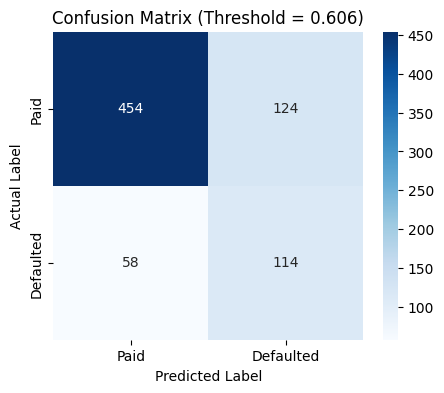

In [11]:
# Evaluate model on unseen Test Set
model.eval()
test_probs = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        test_probs.extend(probs.numpy())
        test_targets.extend(y_batch.numpy())

test_probs = np.array(test_probs).ravel()
test_targets = np.array(test_targets).ravel()

# Convert probabilities to 0 or 1 using the tuned threshold
test_preds = (test_probs >= best_threshold).astype(int)

# Print Final Test Metrics
print("==========================================")
print(f"FINAL TEST EVALUATION (Threshold = {best_threshold:.3f})")
print("==========================================")
print(f"Accuracy:  {accuracy_score(test_targets, test_preds):.4f}")
print(f"Precision: {precision_score(test_targets, test_preds, zero_division=0):.4f}")
print(f"Recall:    {recall_score(test_targets, test_preds, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(test_targets, test_preds, zero_division=0):.4f}")
print("==========================================")
print("")
print("Classification Report:")
print(classification_report(test_targets, test_preds, target_names=['Paid (0)', 'Defaulted (1)']))

# Plot Confusion Matrix
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid', 'Defaulted'], yticklabels=['Paid', 'Defaulted'])
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.3f})")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()
